In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,
    Dropout, RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

C:\Users\mirza\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

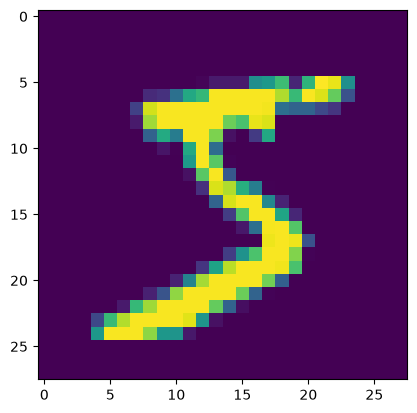

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [5]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [6]:
X_train, X_test = X_train/255.0 , X_test/255.0

In [7]:
L2_REG = 1e-4

model = models.Sequential([
    # 1. Fixed Input Shape for MNIST (28x28 grayscale)
    layers.Input(shape=(28, 28, 1)),

    # 2. Removed RandomFlip (Flipping digits destroys them!)
    # Kept a tiny bit of rotation and zoom which is safe for handwriting
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),

    # Block 1 (Output becomes 14x14)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    layers.Dropout(0.2),

    # Block 2 (Output becomes 7x7)
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    layers.Dropout(0.3),

    # Block 3 (Output becomes 3x3)
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='leaky_relu',
                  kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    layers.Dropout(0.4),

    # Blocks 4 and 5 REMOVED to prevent spatial crash!

    # Final Classifier
    layers.Flatten(), # Flatten is usually better than GlobalAveragePooling for MNIST
    layers.Dense(128, activation='leaky_relu', kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # 10 classes (digits 0-9), logits output
    layers.Dense(10)  
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation (RandomRotation)     │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 437,610 (1.67 MB)

 Trainable params: 436,458 (1.66 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [9]:
BATCH_SIZE = 32
actual_train_size = int(len(X_train) * 0.85)
steps_per_epoch = actual_train_size // BATCH_SIZE
TARGET_EPOCHS_FOR_DECAY = 150

train_labels_oh = tf.keras.utils.to_categorical(y_train, num_classes=10)
test_labels_oh = tf.keras.utils.to_categorical(y_test, num_classes=10)

lr_schedule = CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * TARGET_EPOCHS_FOR_DECAY,
    alpha=0.01,
)

optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=1,
    verbose=1,
    mode="min",
    restore_best_weights=True,
)

checkpoint = ModelCheckpoint(
    "best_model_mnist.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks_list = [early_stopping, checkpoint]

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    X_train, train_labels_oh, batch_size=BATCH_SIZE,
    epochs=10,
    callbacks=callbacks_list,
    validation_split=0.15,
)

Epoch 1/10
1593/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9058 - loss: 0.9490
Epoch 1: val_loss improved from None to 0.74222, saving model to best_model_mnist.keras

Epoch 1: finished saving model to best_model_mnist.keras
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 85s 49ms/step - accuracy: 0.9058 - loss: 0.9490 - val_accuracy: 0.9833 - val_loss: 0.7422
Epoch 2/10
1593/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9718 - loss: 0.7464
Epoch 2: val_loss improved from 0.74222 to 0.68694, saving model to best_model_mnist.keras

Epoch 2: finished saving model to best_model_mnist.keras
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.9718 - loss: 0.7463 - val_accuracy: 0.9896 - val_loss: 0.6869
Epoch 3/10
1593/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9796 - loss: 0.7002
Epoch 3: val_loss improved from 0.68694 to 0.63593, saving model to best_model_mnist.keras

Epoch 3: finished saving model to best_model_mnist.keras
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - 

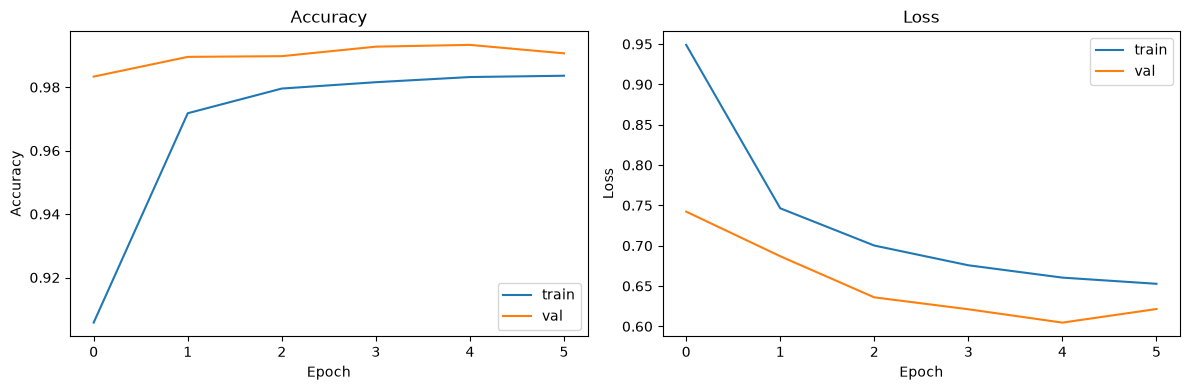

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models

# 1. Create a clean inference model that skips the data augmentation layers
inference_model = models.Sequential(model.layers[2:])

# 2. Prepare test data
X_test_clean = X_test.astype(np.float32)
if len(X_test_clean.shape) == 3:
    X_test_clean = X_test_clean.reshape(-1, 28, 28, 1)
y_test_clean = y_test.reshape(-1)

# 3. Generate predictions safely using the inference model
print("Generating predictions...")
logits = inference_model.predict(X_test_clean, batch_size=256, verbose=1)

# 4. Convert logits to probabilities and get final predictions
y_pred_proba = tf.nn.softmax(logits).numpy()
y_pred = np.argmax(y_pred_proba, axis=1)

# 5. Binarize labels for metrics
classes = np.unique(y_test_clean)
y_test_bin = label_binarize(y_test_clean, classes=classes)

# 6. Calculate and print all metrics
print("\n=== MNIST Evaluation Metrics ===")
print(f"Accuracy:             {accuracy_score(y_test_clean, y_pred):.4f}")
print(f"Precision (macro):    {precision_score(y_test_clean, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):       {recall_score(y_test_clean, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score (macro):     {f1_score(y_test_clean, y_pred, average='macro', zero_division=0):.4f}")
print(f"ROC-AUC (ovr):        {roc_auc_score(y_test_clean, y_pred_proba, multi_class='ovr', average='macro'):.4f}")
print(f"PR-AUC (macro):       {average_precision_score(y_test_bin, y_pred_proba, average='macro'):.4f}")
print(f"MCC:                  {matthews_corrcoef(y_test_clean, y_pred):.4f}")

# 7. Print classification report
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test_clean, y_pred, digits=4))

y_true = y_test_clean
probs = y_pred_proba

Generating predictions...
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step

=== MNIST Evaluation Metrics ===
Accuracy:             0.9925
Precision (macro):    0.9925
Recall (macro):       0.9925
F1 Score (macro):     0.9925
ROC-AUC (ovr):        1.0000
PR-AUC (macro):       0.9997
MCC:                  0.9917

=== Detailed Classification Report ===
              precision    recall  f1-score   support

           0     0.9990    0.9908    0.9949       980
           1     0.9965    0.9894    0.9929      1135
           2     0.9923    0.9942    0.9932      1032
           3     0.9902    0.9970    0.9936      1010
           4     0.9869    0.9980    0.9924       982
           5     0.9989    0.9865    0.9927       892
           6     0.9865    0.9937    0.9901       958
           7     0.9893    0.9932    0.9913      1028
           8     0.9888    0.9928    0.9908       974
           9     0.9970    0.9891    0.9930      1009

    accuracy                         0.9925     10000
   macr

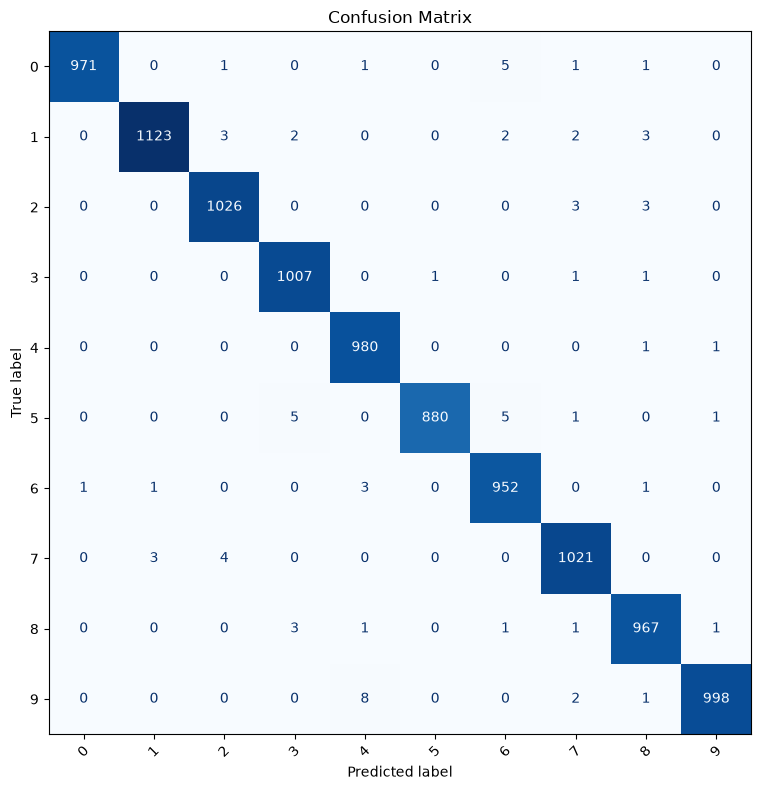

In [24]:
class_names = [str(i) for i in range(10)]
cm = confusion_matrix(y_true, y_pred, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')


plt.tight_layout()
plt.show()

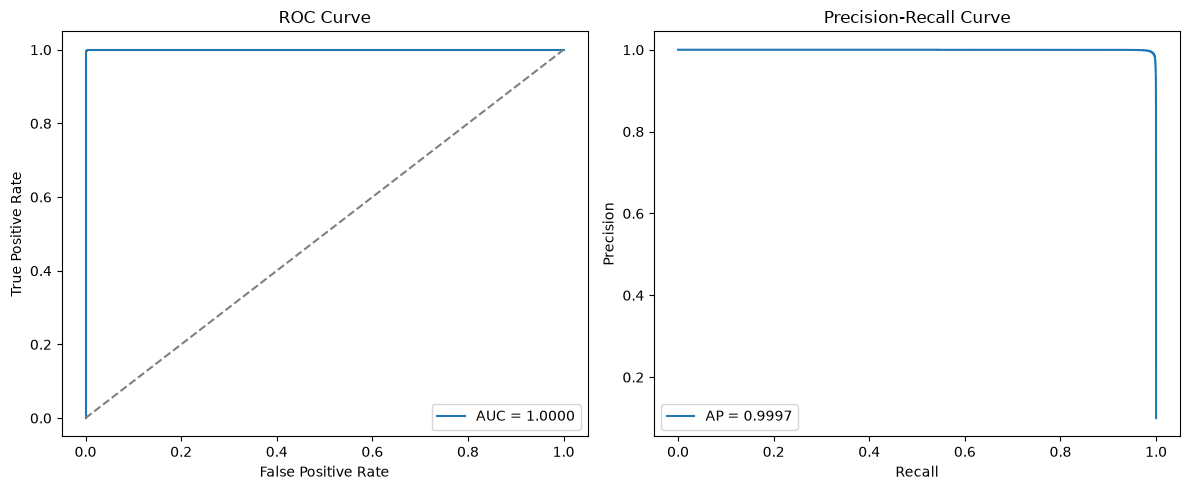

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Flatten the arrays to calculate a single 'micro-average' curve for multi-class
y_test_flat = y_test_bin.ravel()
y_pred_proba_flat = y_pred_proba.ravel()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test_flat, y_pred_proba_flat)
# We keep your previous 'macro' AUC score for the label to match your text metrics
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro') 

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# --- Precision-Recall Curve ---
prec, rec, thresholds = precision_recall_curve(y_test_flat, y_pred_proba_flat)
pr_auc = average_precision_score(y_test_bin, y_pred_proba, average='macro')

axes[1].plot(rec, prec, label=f"AP = {pr_auc:.4f}")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9925

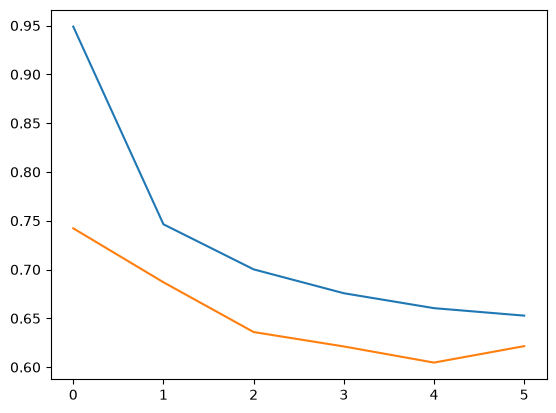

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

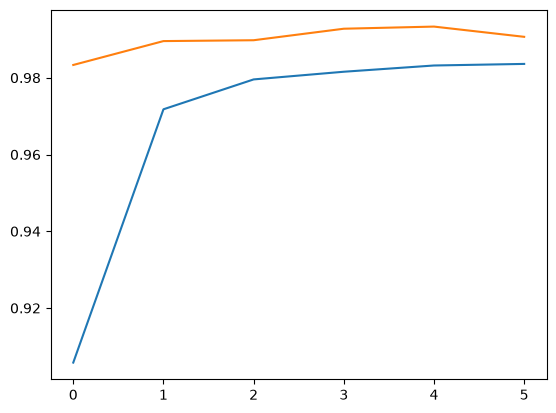

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

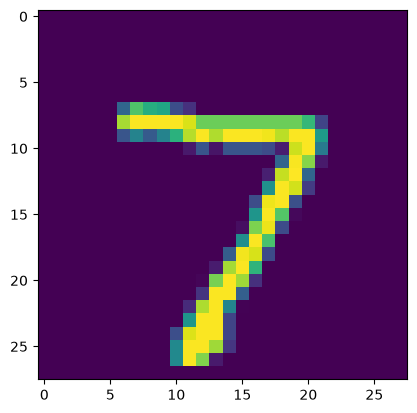

In [29]:
plt.imshow(X_test[0])

In [30]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([7])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
The model predicts this is a: 5
Confidence: 22.99%



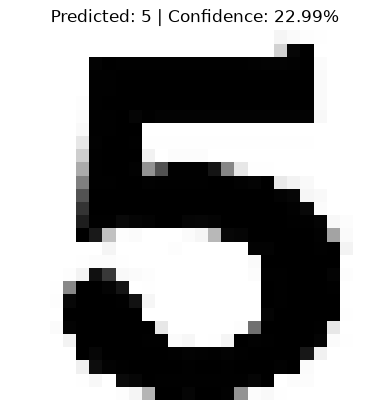

In [34]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("best_model_mnist.keras")

image_path = "download.jpg" 


img = image.load_img(image_path, target_size=(28, 28), color_mode="grayscale")
img_array = image.img_to_array(img)



img_array = img_array / 255.0


img_batch = np.expand_dims(img_array, axis=0)

raw_predictions = model.predict(img_batch)


probabilities = tf.nn.softmax(raw_predictions).numpy()[0]

predicted_digit = np.argmax(probabilities)
confidence = np.max(probabilities) * 100

print(f"The model predicts this is a: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%\n")

plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_digit} | Confidence: {confidence:.2f}%")
plt.axis('off')
plt.show()